In [52]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import  torch.nn.functional as F


In [53]:
"""
What is the neuron???
A neuron is the fundamental building block of a neural network. It receives input signals, 
processes them by calculating a weighted sum and adding a bias, and then applies an activation function 
(such as ReLU, Sigmoid, or Tanh) to produce an output signal that is transmitted to the next
layer.
"""
inputs = torch.tensor([2.0,3.0])

weights = torch.tensor([0.5,0.3])

bais =0.1

weighted_sum = weights[0]*inputs[0] + weights[1]*inputs[1]

print("neuron")
print("inputs: ", inputs)
print("weights: " , weights)
print("bais: ", bais )
print("weighted sum: ",weighted_sum)


neuron
inputs:  tensor([2., 3.])
weights:  tensor([0.5000, 0.3000])
bais:  0.1
weighted sum:  tensor(1.9000)


In [54]:

"""
Simple Artificial Neuron implementation using PyTorch.

This class initializes a neuron with random weights and a zero bias, 
providing a method to compute the weighted sum (linear combination) 
of input features.
"""

class Neuron:
    def __init__(self,num_inputs):
        self.weights = torch.randn(num_inputs)*0.1

        self.bias = torch.tensor(0.0)
    def weighted_sum(self,inputs):
        return torch.dot(self.weights,inputs) +self.bias

neuron = Neuron(num_inputs = 2)
neuron.weights = torch.tensor([0.5,0.1])
neuron.bias =0.1

inputs = torch.tensor([2.0,3.0])
result = neuron.weighted_sum(inputs)
print(result)


tensor(1.4000)


In [55]:
class Neuron:
    def __init__(self,num_inputs):
        self.weights = torch.randn(num_inputs)*0.1

        self.bias = torch.tensor(0.0)
    def weighted_sum(self,inputs):
        return torch.dot(self.weights,inputs) +self.bias
    def sigmoid(self,x):
        return (1/(1+torch.exp(-x)))

neuron = Neuron(num_inputs = 2)
neuron.weights = torch.tensor([0.5,0.1])
neuron.bias =0.1

inputs = torch.tensor([2.0,3.0])
result = neuron.weighted_sum(inputs)
print(result)
final_result = neuron.sigmoid(result)
print(final_result)

tensor(1.4000)
tensor(0.8022)


Weighted Sum: 1.399999976158142
Sigmoid Output: 0.8021839261054993
Forward Output: 0.8021839261054993

First 10 rows of the table:
   Input x1=x2  Weighted Sum (z)  Sigmoid Output
0    -5.000000         -2.900000        0.052154
1    -4.795918         -2.777551        0.058549
2    -4.591837         -2.655102        0.065675
3    -4.387755         -2.532653        0.073601
4    -4.183673         -2.410204        0.082398
5    -3.979592         -2.287755        0.092142
6    -3.775510         -2.165306        0.102910
7    -3.571429         -2.042857        0.114776
8    -3.367347         -1.920408        0.127816
9    -3.163265         -1.797959        0.142100


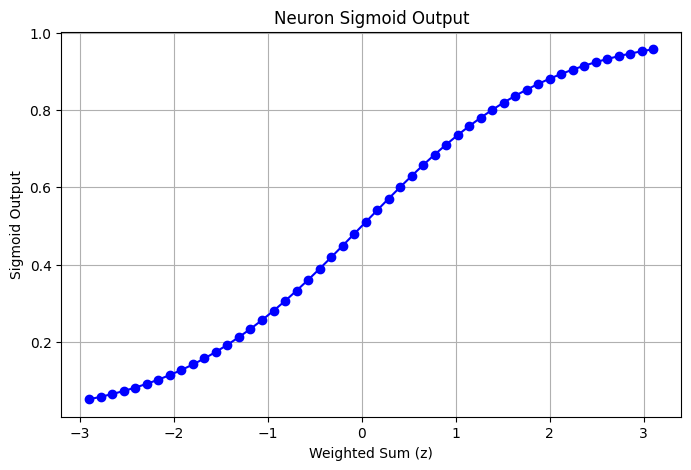

In [56]:
import torch


class Neuron:
    def __init__(self, num_inputs):
        self.weights = torch.randn(num_inputs) * 0.1
        self.bias = torch.tensor(0.0)

    def weighted_sum(self, inputs):
        return torch.dot(self.weights, inputs) + self.bias

    def sigmoid(self, x):
        return 1 / (1 + torch.exp(-x))

    def forward(self, inputs):
        return self.sigmoid(self.weighted_sum(inputs))

neuron = Neuron(num_inputs=2)
neuron.weights = torch.tensor([0.5, 0.1])
neuron.bias = torch.tensor(0.1)

inputs = torch.tensor([2.0, 3.0])

result = neuron.weighted_sum(inputs)
print("Weighted Sum:", result.item())

final_result = neuron.sigmoid(result)
print("Sigmoid Output:", final_result.item())

final_result_2 = neuron.forward(inputs)
print("Forward Output:", final_result_2.item())

x_values = torch.linspace(-5, 5, 50)
weighted_sums = []
sigmoid_outputs = []

for x in x_values:
    inputs = torch.tensor([x, x])
    z = neuron.weighted_sum(inputs)
    y = neuron.forward(inputs)
    weighted_sums.append(z.item())
    sigmoid_outputs.append(y.item())

table = pd.DataFrame({
    "Input x1=x2": x_values.numpy(),
    "Weighted Sum (z)": weighted_sums,
    "Sigmoid Output": sigmoid_outputs
})

print("\nFirst 10 rows of the table:")
print(table.head(10))

plt.figure(figsize=(8,5))
plt.plot(weighted_sums, sigmoid_outputs, color='blue', marker='o')
plt.xlabel("Weighted Sum (z)")
plt.ylabel("Sigmoid Output")
plt.title("Neuron Sigmoid Output")
plt.grid(True)
plt.show()


In [57]:
"""
multilayer neural network
"""
class MultiNeuron:
    def __init__(self,num_inputs,num_neurons):
        self.weights = torch.randn(num_neurons,num_inputs)*0.1
        self.biases = torch.randn(num_neurons)
    
    def weighted_sum(self,inputs):
        return inputs @ self.weights.T+self.biases

    def sigmoid(self,x):
        return torch.sigmoid(x)
    
    def forward(self,inputs):
        weighted_sum = self.weighted_sum(inputs)
        output = self.sigmoid(weighted_sum)
        return output

layer =  MultiNeuron(num_inputs = 2 ,num_neurons = 3)
layer.weights = torch.tensor([[0.5,0.3],[0.5,0.3],[0.5,0.3]])
layer.biases  = torch.tensor([0.1,0.2,0.3])

inputs =torch.tensor([2.0,3.0])
results = layer.weighted_sum(inputs)

final_results = layer.forward(inputs)
print(final_results)

tensor([0.8808, 0.8909, 0.9002])


In [58]:
class MultiNeuron:
    def __init__(self, num_inputs, num_neurons):
        self.num_inputs = num_inputs
        self.num_neurons = num_neurons
        self.weights = torch.randn(num_neurons, num_inputs) * 0.1
        self.biases = torch.randn(num_neurons, dtype=torch.float32)
    
    def weighted_sum(self, inputs):
        return inputs @ self.weights.T + self.biases

    def sigmoid(self, x):
        return 1 / (1 + torch.exp(-x))

    def forward(self, inputs):
        self.inputs = inputs
        self.z = self.weighted_sum(inputs)
        self.output = self.sigmoid(self.z)
        return self.output

    def backward(self, d_output, learning_rate=0.1):
        delta = d_output * (self.output * (1 - self.output))
        d_weights = delta.unsqueeze(1) @ self.inputs.unsqueeze(0)
        d_biases = delta
        self.weights -= learning_rate * d_weights
        self.biases  -= learning_rate * d_biases
        return delta @ self.weights

class DeepNeuralNetwork:
    def __init__(self, layers_dims):
        self.layers = [MultiNeuron(layers_dims[i], layers_dims[i+1]) 
                       for i in range(len(layers_dims)-1)]
    
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, loss_grad, learning_rate=0.1):
        grad = loss_grad
        for layer in reversed(self.layers):
            grad = layer.backward(grad, learning_rate)

    def train(self, X, Y, epochs=1000, learning_rate=0.1):
        for epoch in range(epochs):
            total_loss = 0
            for x, y in zip(X, Y):
                x = torch.tensor(x, dtype=torch.float32)
                y = torch.tensor(y, dtype=torch.float32)
                output = self.forward(x)
                loss = (output - y) ** 2 / 2
                total_loss += loss.sum().item()
                loss_grad = output - y
                self.backward(loss_grad, learning_rate)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

X = [[2.0, 3.0], [1.0, 0.5]]
Y = [[1.0, 0.0], [0.0, 1.0]]

dnn = DeepNeuralNetwork([2, 3, 2])
dnn.train(X, Y, epochs=1000, learning_rate=0.1)

for x in X:
    out = dnn.forward(torch.tensor(x, dtype=torch.float32))
    print(f"Input: {x}, Output: {out.detach().numpy()}")


Epoch 0, Loss: 0.5505
Epoch 100, Loss: 0.4722
Epoch 200, Loss: 0.4221
Epoch 300, Loss: 0.3400
Epoch 400, Loss: 0.2532
Epoch 500, Loss: 0.1785
Epoch 600, Loss: 0.1257
Epoch 700, Loss: 0.0915
Epoch 800, Loss: 0.0694
Epoch 900, Loss: 0.0547
Input: [2.0, 3.0], Output: [0.8721333  0.13451308]
Input: [1.0, 0.5], Output: [0.1600823 0.8310317]


In [59]:

class Conv2DLayer:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.weights = torch.randn(out_channels, in_channels, kernel_size, kernel_size) * 0.1
        self.biases = torch.randn(out_channels, dtype=torch.float32)

    def forward(self, x):
        self.input = x
        batch, channels, height, width = x.shape
        out_height = (height - self.kernel_size) // self.stride + 1
        out_width  = (width  - self.kernel_size) // self.stride + 1
        self.output = torch.zeros((batch, self.out_channels, out_height, out_width))
        for b in range(batch):
            for oc in range(self.out_channels):
                for i in range(0, out_height):
                    for j in range(0, out_width):
                        region = x[b, :, i*self.stride:i*self.stride+self.kernel_size, j*self.stride:j*self.stride+self.kernel_size]
                        self.output[b, oc, i, j] = torch.sum(region * self.weights[oc]) + self.biases[oc]
        return self.output

    def backward(self, d_output, learning_rate=0.01):
        batch, _, out_height, out_width = d_output.shape
        d_input = torch.zeros_like(self.input)
        d_weights = torch.zeros_like(self.weights)
        d_biases = torch.zeros_like(self.biases)
        for b in range(batch):
            for oc in range(self.out_channels):
                for i in range(out_height):
                    for j in range(out_width):
                        region = self.input[b, :, i*self.stride:i*self.stride+self.kernel_size, j*self.stride:j*self.stride+self.kernel_size]
                        d_weights[oc] += d_output[b, oc, i, j] * region
                        d_input[b, :, i*self.stride:i*self.stride+self.kernel_size, j*self.stride:j*self.stride+self.kernel_size] += d_output[b, oc, i, j] * self.weights[oc]
                        d_biases[oc] += d_output[b, oc, i, j]
        self.weights -= learning_rate * d_weights
        self.biases  -= learning_rate * d_biases
        return d_input

x = torch.randn(1, 1, 5, 5)  
conv = Conv2DLayer(in_channels=1, out_channels=2, kernel_size=3)
out = conv.forward(x)
print("Forward output:\n", out)

d_out = torch.ones_like(out)
d_input = conv.backward(d_out, learning_rate=0.01)
print("Gradient w.r.t input:\n", d_input)


Forward output:
 tensor([[[[-0.2481,  1.1018,  0.0039],
          [ 0.0163,  0.0263,  0.9111],
          [ 0.4846,  0.5066,  0.4129]],

         [[ 1.4423,  0.8143,  1.5139],
          [ 1.8030,  0.9208,  1.3891],
          [ 1.4833,  1.2512,  1.1221]]]])
Gradient w.r.t input:
 tensor([[[[ 0.0097, -0.1296, -0.3132, -0.3229, -0.1836],
          [-0.0104, -0.0920, -0.5621, -0.5518, -0.4702],
          [ 0.0653, -0.0946, -0.5906, -0.6558, -0.4960],
          [ 0.0556,  0.0350, -0.2774, -0.3329, -0.3124],
          [ 0.0756, -0.0027, -0.0284, -0.1041, -0.0258]]]])


In [60]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * np.power(x, 3))))

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))
